# Fase 1 — Inspección y análisis exploratorio
### NASA C-MAPSS FD001 — sobre la salida de Fase 0

**Qué es y qué NO es esta fase.** Es análisis descriptivo y
visualización — no toma ninguna decisión de preprocesado nueva. La
selección de sensores informativos y la normalización ya se decidieron
en [`fase0_preprocesado.ipynb`](fase0_preprocesado.ipynb); aquí se
**reutilizan** (importadas, no reimplementadas) para no repetir el
error que motivó esta auditoría: la Fase 1 original definía su propia
normalización (`normalize_per_unit`, per motor, con leakage) en vez de
depender de una única fuente de verdad.

**Referencias:**
- Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). *Damage
  propagation modeling for aircraft engine run-to-failure simulation.*
  PHM 2008, Denver, CO.
- Ramasso, E., & Saxena, A. (2014). *Performance benchmarking and
  analysis of prognostic methods for CMAPSS datasets.* IJPHM, 5(2).
  DOI: 10.36001/ijphm.2014.v5i2.2236.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase1_carga_inspeccion as f1
import fase0_preprocesado as f0


In [2]:
import inspect

def show_source(func, note=None):
    """Código fuente REAL de una función importada (no una copia), con
    su ubicación exacta — visibilidad total sin salir del notebook, sin
    duplicar la única implementación que vive en el .py."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice — ubicación exacta
impresa por `show_source()` justo antes de su primer uso):

| Función | De dónde | Para qué |
|---|---|---|
| `load_cmapss` | `fase0_preprocesado.py` | Carga train/test/RUL (reutilizada, no redefinida) |
| `select_informative_sensors` | `fase0_preprocesado.py` | Filtro de varianza — misma decisión que Fase 0 |
| `inspect_dataset` | `fase1_carga_inspeccion.py` | Estadísticas descriptivas |
| `plot_sensor_variance` / `plot_life_distribution` / `plot_sensor_distributions` | `fase1_carga_inspeccion.py` | Visualizaciones exploratorias |
| `plot_global_normalized_sample` | `fase1_carga_inspeccion.py` | Reemplaza la demo de normalización per-motor (bug) por la global (Fase 0) |
| `build_subsets_comparison` | `fase1_carga_inspeccion.py` | Carga + normaliza + describe los 4 subdatasets |
| `plot_subsets_comparison` / `plot_operating_conditions` | `fase1_carga_inspeccion.py` | Comparativa FD001-FD004 -- extension |


## 1. Carga de datos

Se reutiliza `f0.load_cmapss` — la misma función, con la misma
asignación posicional de nombres de columna, que usa Fase 0. No hay una
segunda implementación de la carga de datos en todo el proyecto.


In [3]:
show_source(f0.load_cmapss)

📍 load_cmapss  —  scripts\fase0_preprocesado.py:151
------------------------------------------------------------------------------
def load_cmapss(subset: str = "FD001", data_dir: str = DATA_DIR) -> tuple:
    """Carga train/test/RUL crudos de NASA C-MAPSS."""
    train_path = os.path.join(data_dir, f"train_{subset}.txt")
    test_path  = os.path.join(data_dir, f"test_{subset}.txt")
    rul_path   = os.path.join(data_dir, f"RUL_{subset}.txt")

    train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=COLUMNS)
    test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=COLUMNS)
    rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])

    train_df["engine_id"] = train_df["engine_id"].astype(int)
    train_df["cycle"]     = train_df["cycle"].astype(int)
    test_df["engine_id"]  = test_df["engine_id"].astype(int)
    test_df["cycle"]      = test_df["cycle"].astype(int)

    return train_df, test_df, rul_df



In [4]:
train_df, test_df, rul_df = f0.load_cmapss("FD001")
print(f"Train: {train_df.shape} | Test: {test_df.shape} | RUL: {rul_df.shape}")
train_df.head()


Train: (20631, 26) | Test: (13096, 26) | RUL: (100, 1)


,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Inspección descriptiva

Estadísticas básicas del dataset: dimensiones, motores, distribución de
vida útil, valores nulos y resumen por sensor (media, std, min, max,
coeficiente de variación). Nada de esto requiere ninguna decisión de
diseño — es solo describir los datos tal cual llegan.


In [5]:
show_source(f1.inspect_dataset)

📍 inspect_dataset  —  scripts\fase1_carga_inspeccion.py:101
------------------------------------------------------------------------------
def inspect_dataset(train_df: pd.DataFrame, test_df: pd.DataFrame,
                     rul_df: pd.DataFrame) -> pd.DataFrame:
    """Estadísticas generales + resumen por sensor (train)."""
    print(f"\n{'DIMENSIONES':─<50}")
    print(f"  Train : {train_df.shape[0]:>8,} filas  ×  {train_df.shape[1]} columnas")
    print(f"  Test  : {test_df.shape[0]:>8,} filas  ×  {test_df.shape[1]} columnas")
    print(f"  RUL   : {rul_df.shape[0]:>8,} valores")

    n_train_eng = train_df["engine_id"].nunique()
    n_test_eng  = test_df["engine_id"].nunique()
    print(f"\n{'MOTORES':─<50}")
    print(f"  Train : {n_train_eng} motores  |  Test : {n_test_eng} motores")

    life = train_df.groupby("engine_id")["cycle"].max()
    print(f"\n{'VIDA ÚTIL POR MOTOR (Train)':─<50}")
    print(f"  Mínima/Máxima : {life.min()} / {life.max()} ciclos")
    print(f"  Media 

In [6]:
sensor_stats = f1.inspect_dataset(train_df, test_df, rul_df)
sensor_stats.round(4)



DIMENSIONES───────────────────────────────────────
  Train :   20,631 filas  ×  26 columnas
  Test  :   13,096 filas  ×  26 columnas
  RUL   :      100 valores

MOTORES───────────────────────────────────────────
  Train : 100 motores  |  Test : 100 motores

VIDA ÚTIL POR MOTOR (Train)───────────────────────
  Mínima/Máxima : 128 / 362 ciclos
  Media ± std   : 206.3 ± 46.3 ciclos
  Mediana       : 199 ciclos

VALORES NULOS─────────────────────────────────────
  Train : 0  |  Test : 0


,Media,Std,Mín,Máx,Varianza,CV_%
Sensor,,,,,,
s1,518.6700,0.0000,518.6700,518.6700,0.0000,0.00
s2,642.6809,0.5001,641.2100,644.5300,0.2501,0.08
s3,1590.5231,6.1311,1571.0400,1616.9100,37.5910,0.39
s4,1408.9338,9.0006,1382.2500,1441.4900,81.0109,0.64
s5,14.6200,0.0000,14.6200,14.6200,0.0000,0.00
s6,21.6098,0.0014,21.6000,21.6100,0.0000,0.01
s7,553.3677,0.8851,549.8500,556.0600,0.7834,0.16
s8,2388.0967,0.0710,2387.9000,2388.5600,0.0050,0.00
s9,9065.2429,22.0829,9021.7300,9244.5900,487.6536,0.24


**Nota de consistencia:** la vida útil media en train (206.3 ±
46.3 ciclos, rango 128-362) coincide exactamente con la cifra que cita
`fase6_documentacion.py` en el informe técnico — confirma que esta
reimplementación describe los mismos datos crudos que el resto del
proyecto, no una versión distinta.


## 3. Selección de sensores informativos (recalculada, no redecidida)

Se recalcula aquí — usando la misma función de Fase 0 — únicamente como
**comprobación de consistencia**: si alguna vez el dataset cambiara o
alguien tocara el umbral en `fase0_preprocesado.py` sin querer, esta
celda lo detectaría por sí sola (el `assert` interno de
`select_informative_sensors` compara contra `INFORMATIVE_EXPECTED` y
lanza un warning si difieren).


In [7]:
show_source(f0.select_informative_sensors)

📍 select_informative_sensors  —  scripts\fase0_preprocesado.py:173
------------------------------------------------------------------------------
def select_informative_sensors(train_df: pd.DataFrame,
                                std_threshold: float = STD_THRESHOLD,
                                subset: str = None) -> tuple:
    """
    Descarta sensores con std ~0 en train (no aportan señal de
    degradación). El umbral y el criterio se calculan SOLO sobre train,
    nunca sobre test, para no filtrar información del test set en una
    decisión de diseño del pipeline.

    El guardrail de consistencia contra INFORMATIVE_EXPECTED (usado por
    fase2/fase5/fase7) solo es válido para FD001: pásalo explícitamente
    en `subset` para activarlo. Para FD002-FD004 el conjunto de sensores
    informativos es distinto (más condiciones operacionales => algunos
    sensores que en FD001 son ruido de instrumentación pasan a tener
    varianza real) y no debe compararse contra la lista de 

In [8]:
informative, low_var = f0.select_informative_sensors(train_df)
print(f"Informativos ({len(informative)}): {informative}")
print(f"Descartados  ({len(low_var)}): {low_var}")
assert informative == f0.INFORMATIVE_EXPECTED
print("\n✓ Coincide con la selección de Fase 0.")


Informativos (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Descartados  (7): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

✓ Coincide con la selección de Fase 0.


In [9]:
show_source(f1.plot_sensor_variance)

📍 plot_sensor_variance  —  scripts\fase1_carga_inspeccion.py:137
------------------------------------------------------------------------------
def plot_sensor_variance(train_df: pd.DataFrame, low_var: list, save_path: str = None):
    """Barras de std por sensor, marcando los descartados por Fase 0."""
    stds = train_df[f0.SENSOR_COLS].std().sort_values(ascending=True)
    colors = [PALETTE["danger"] if s in low_var else PALETTE["primary"] for s in stds.index]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(stds.index, stds.values, color=colors, edgecolor="white",
                   linewidth=0.5, height=0.7)
    ax.axvline(f0.STD_THRESHOLD, color=PALETTE["danger"], linestyle="--",
               linewidth=1.5, label=f"Umbral std = {f0.STD_THRESHOLD}")
    for bar, val in zip(bars, stds.values):
        ax.text(val + stds.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8, color=PALETTE["text"])
    from matplotlib

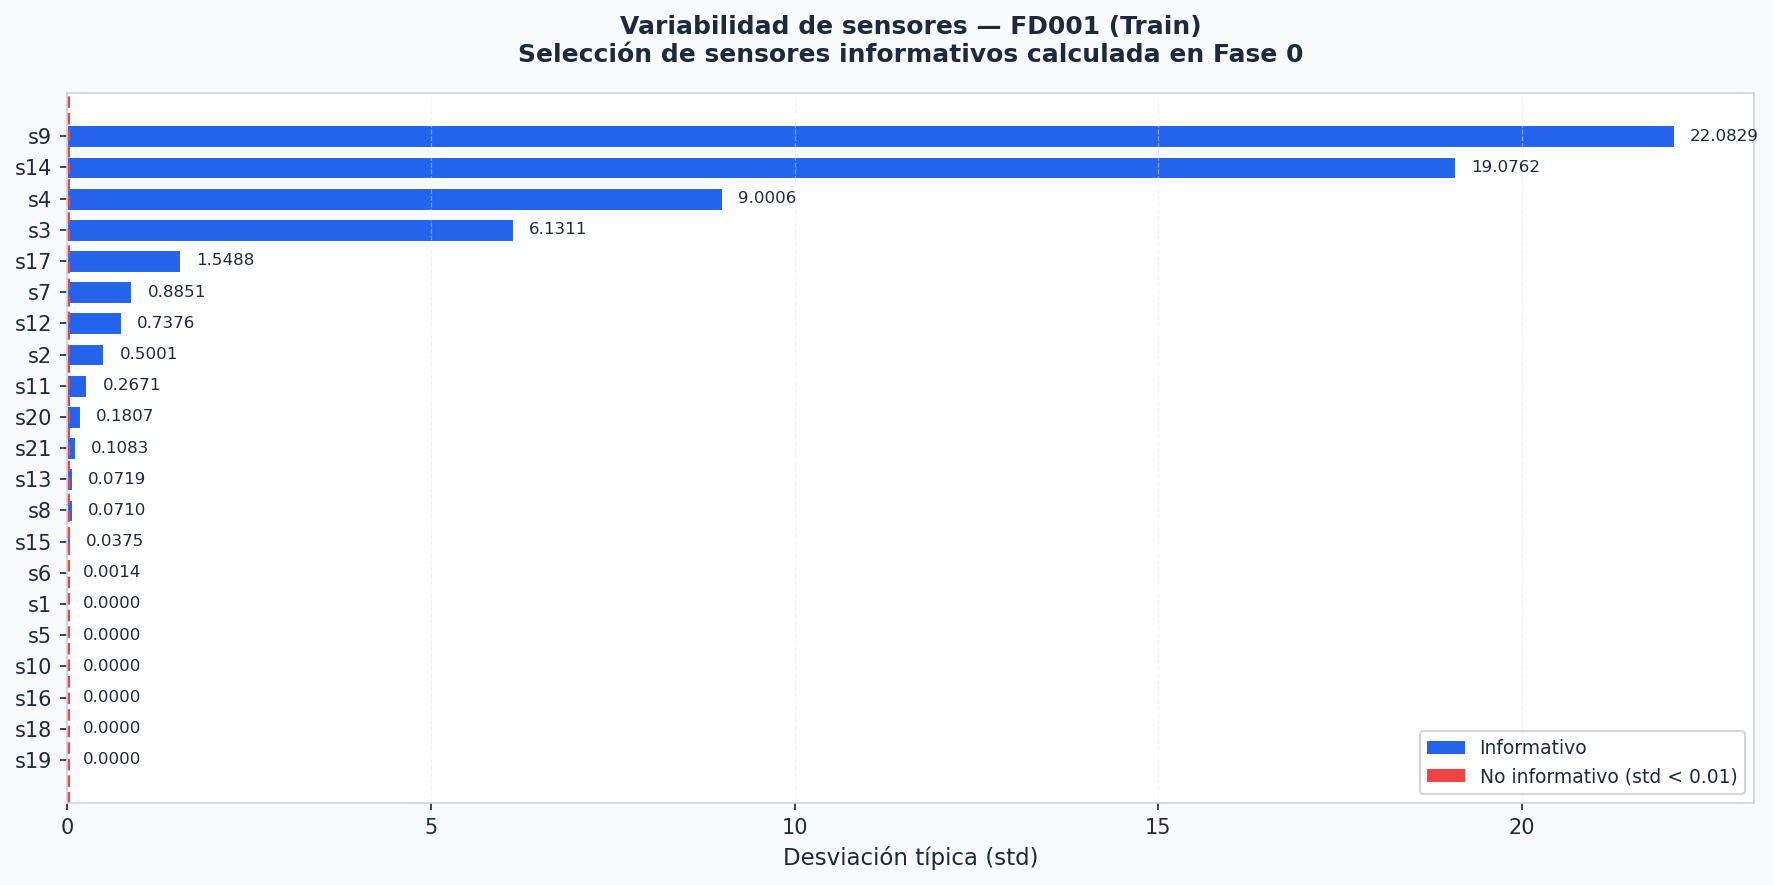

In [10]:
from IPython.display import Image, display
f1.plot_sensor_variance(train_df, low_var, save_path=f"{f0.FIG_DIR}/f1_01_sensor_variance.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_01_sensor_variance.png"))


## 4. Distribución de vida útil

La forma de esta distribución es la base empírica del cap de RUL a 125
ciclos que se aplica en Fase 2 (Heimes, 2008): con una vida media de
~206 ciclos, capear a 125 afecta a una fracción sustancial de los
ciclos de train (concretamente donde RUL_raw > 125), forzando al modelo
a concentrarse en la fase de degradación medible.


In [11]:
show_source(f1.plot_life_distribution)

📍 plot_life_distribution  —  scripts\fase1_carga_inspeccion.py:167
------------------------------------------------------------------------------
def plot_life_distribution(train_df: pd.DataFrame, save_path: str = None):
    life = train_df.groupby("engine_id")["cycle"].max()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(life.values, bins=20, color=PALETTE["primary"], alpha=0.75,
            edgecolor="white", linewidth=0.8, density=True, label="Histograma")
    try:
        kde = gaussian_kde(life.values)
        x_range = np.linspace(life.min() - 10, life.max() + 10, 300)
        ax.plot(x_range, kde(x_range), color=PALETTE["danger"], linewidth=2.5, label="KDE")
    except Exception:
        pass
    ax.axvline(life.mean(), color=PALETTE["accent"], linestyle="--", linewidth=2,
               label=f"Media = {life.mean():.0f} ciclos")
    ax.axvline(life.median(), color=PALETTE["secondary"], linestyle=":", linewidth=2,
               label=f"Mediana = {life.median():.0f} cic

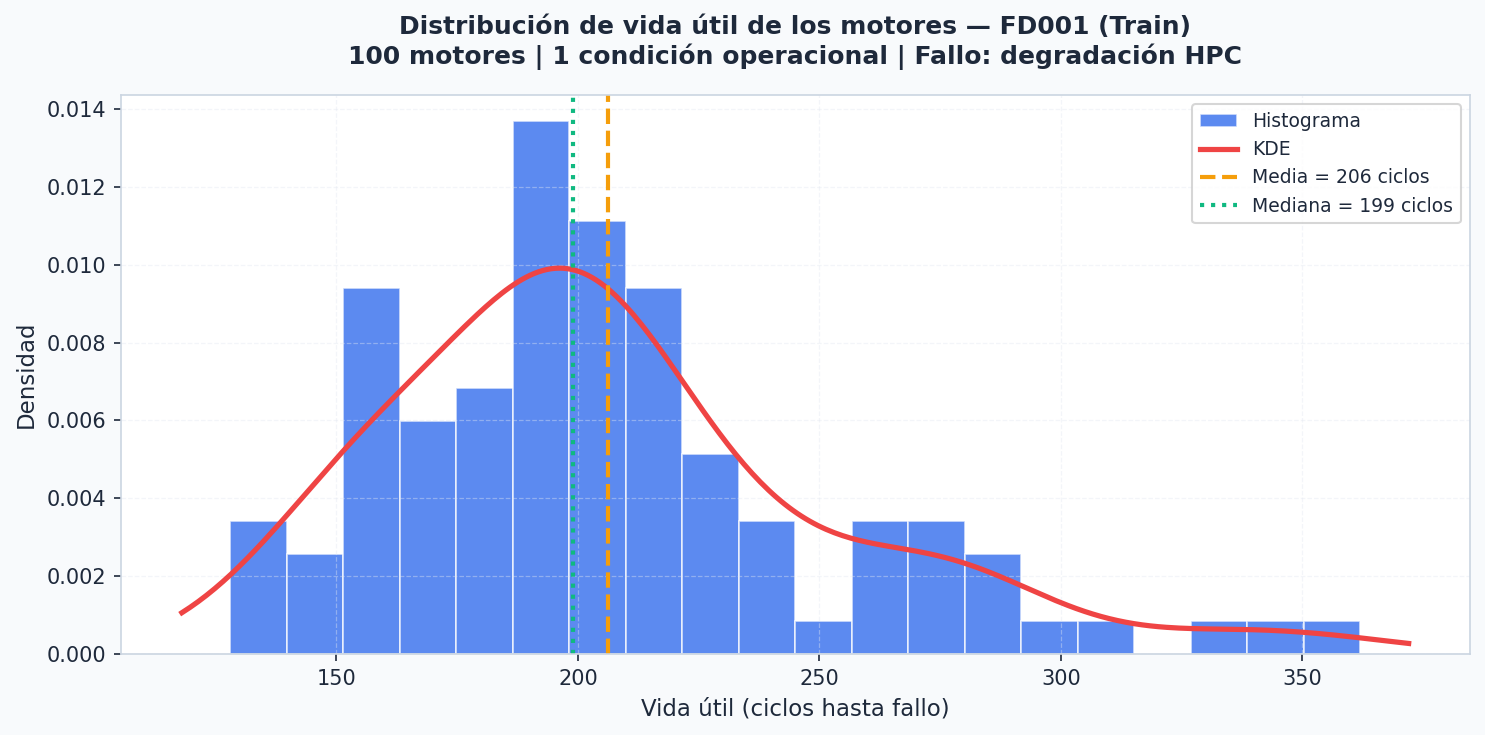

In [12]:
f1.plot_life_distribution(train_df, save_path=f"{f0.FIG_DIR}/f1_02_life_distribution.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_02_life_distribution.png"))


## 5. Distribuciones de sensores informativos

In [13]:
show_source(f1.plot_sensor_distributions)

📍 plot_sensor_distributions  —  scripts\fase1_carga_inspeccion.py:195
------------------------------------------------------------------------------
def plot_sensor_distributions(train_df: pd.DataFrame, informative: list, save_path: str = None):
    n = len(informative)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes_flat = axes.flatten()
    for i, sensor in enumerate(informative):
        ax = axes_flat[i]
        ax.hist(train_df[sensor].dropna(), bins=40, color=PALETTE["primary"],
                alpha=0.8, edgecolor="white", linewidth=0.3)
        ax.set_title(f"{sensor}\n{SENSOR_NAMES[sensor]}", fontsize=8, pad=4)
        ax.set_xlabel("Valor", fontsize=7)
        ax.set_ylabel("Frecuencia", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle("Distribuciones de sensores informativ

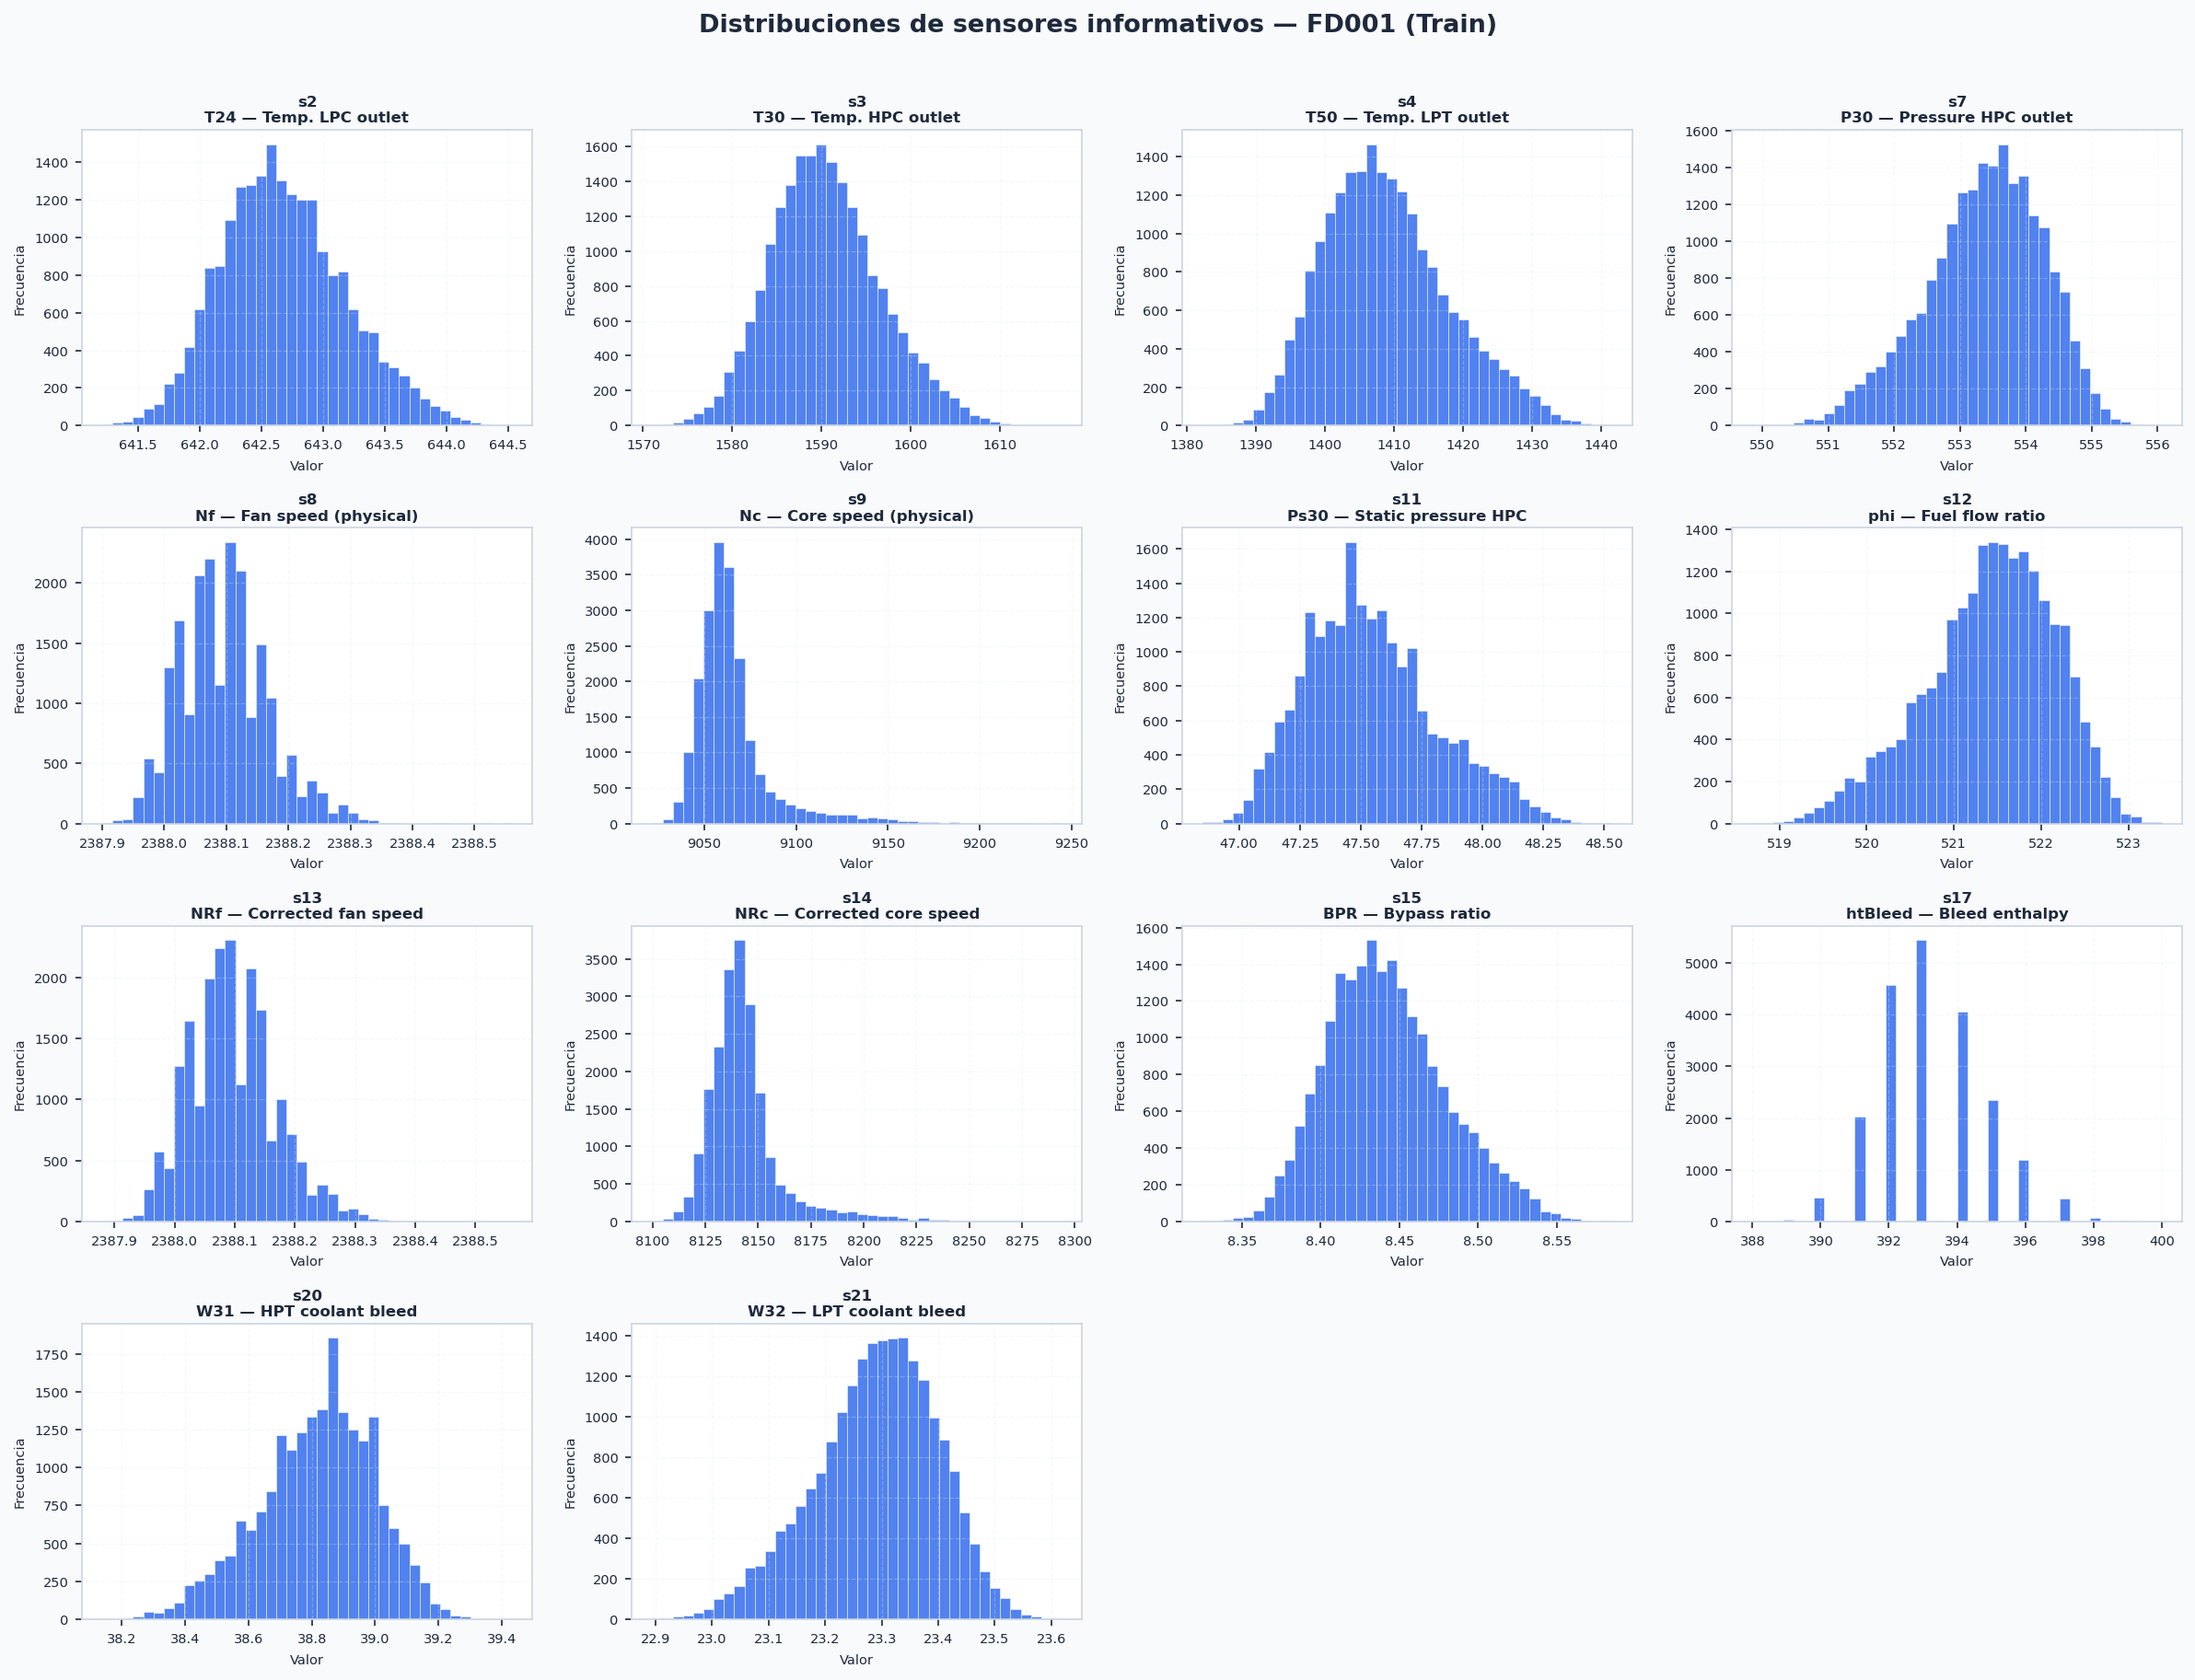

In [14]:
f1.plot_sensor_distributions(train_df, informative, save_path=f"{f0.FIG_DIR}/f1_03_sensor_distributions.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_03_sensor_distributions.png"))


## 6. Efecto de la normalización GLOBAL sobre trayectorias reales

**Por qué esta sección reemplaza a la original.** La Fase 1 original
mostraba aquí el efecto de `normalize_per_unit` — es decir, ilustraba
visualmente el propio sesgo que Fase 0 corrigió (con normalización por
motor, cada trayectoria se reescala a *su propio* rango [0,1],
así que todas lucen visualmente "iguales" independientemente de su
degradación real). Mostrar esa versión aquí sería, como mínimo,
confuso, y en el peor caso induciría a pensar que ese era el
comportamiento correcto.

Con normalización global (Fase 0), el rango de escalado es el mismo
para todos los motores — así que si dos motores muestran niveles
distintos en la gráfica, es una diferencia real de sus trayectorias de
degradación, no un artefacto del escalador.


In [15]:
show_source(f1.plot_global_normalized_sample)

📍 plot_global_normalized_sample  —  scripts\fase1_carga_inspeccion.py:220
------------------------------------------------------------------------------
def plot_global_normalized_sample(train_df: pd.DataFrame, informative: list,
                                   global_scaler, n_motors: int = 5,
                                   save_path: str = None):
    """
    Muestra la señal normalizada GLOBALMENTE (Fase 0) de varios motores,
    para los mismos 3 sensores que usaba la Fase 1 original — pero con
    la corrección: como el escalador es el mismo para todos los
    motores, las diferencias de nivel entre motores en la gráfica son
    reales (reflejan degradación real), no un artefacto de que cada
    motor se reescale a su propio rango [0,1] como ocurría con
    `normalize_per_unit` (el bug corregido en Fase 0).
    """
    sensors_to_plot = [s for s in ["s2", "s3", "s4"] if s in informative] or informative[:3]
    train_norm = f0.apply_global_scaler(train_df, informative, global

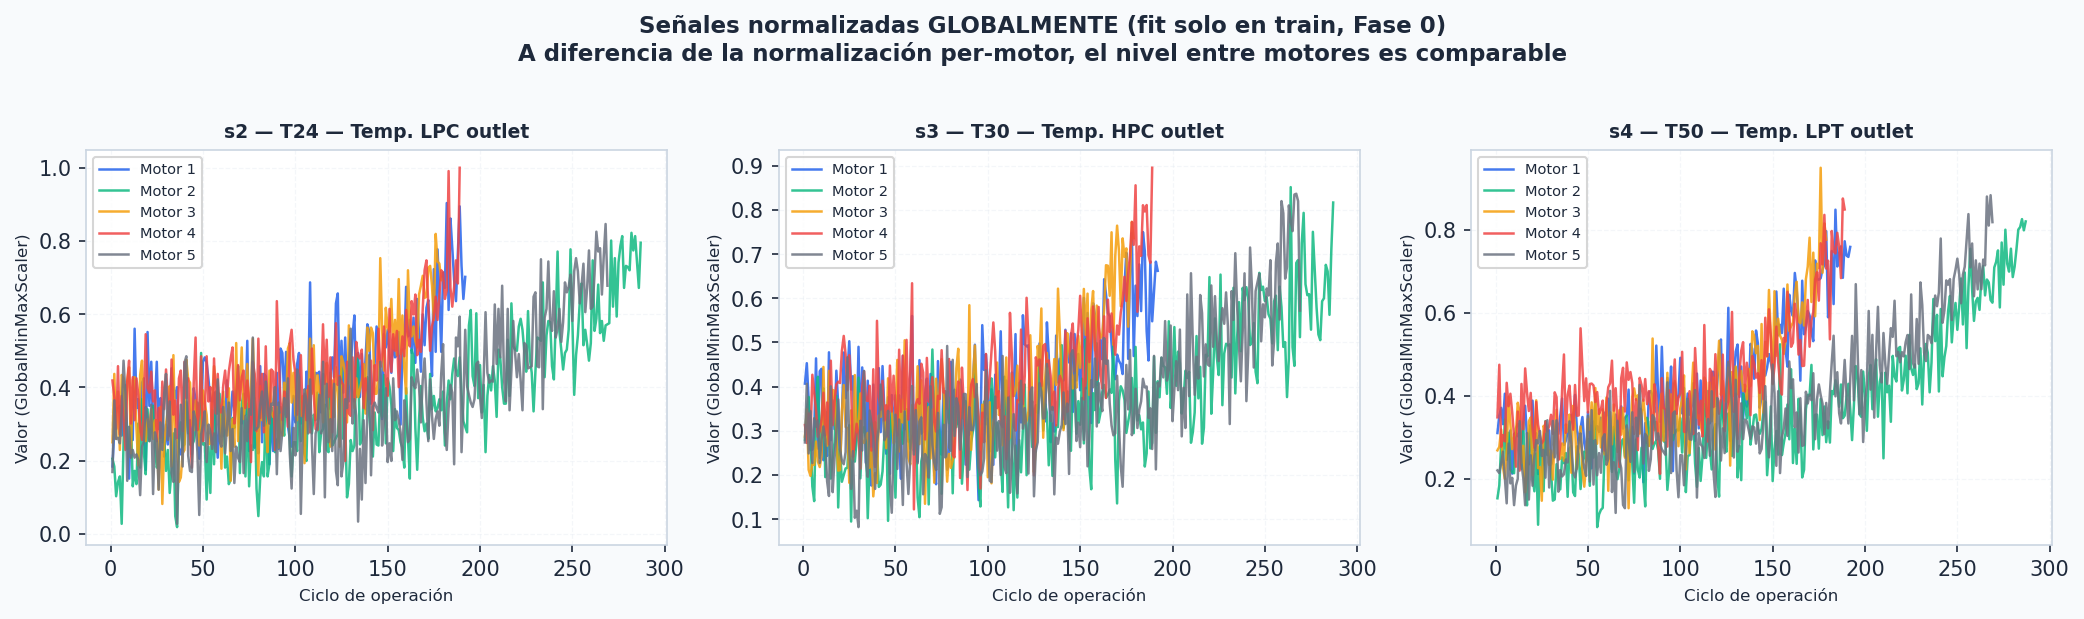

In [16]:
import joblib
global_scaler = joblib.load(f"{f0.MODEL_DIR}/global_sensor_scaler.pkl")
f1.plot_global_normalized_sample(train_df, informative, global_scaler,
                                  save_path=f"{f0.FIG_DIR}/f1_04_normalized_signals.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_04_normalized_signals.png"))


## 7. Extensión (sept. 2026) — comparativa de los 4 subdatasets

Todo lo anterior (secciones 1-6) es el análisis en profundidad de FD001, el subdataset de referencia para el desarrollo. Esta sección lo complementa con una comparativa de los 4 subdatasets (FD001-FD004), reutilizando `f0.normalize_dataset` — la misma que decide, en Fase 0, si aplicar `GlobalMinMaxScaler` (FD001/FD003) o un `MinMaxScaler` por régimen operacional (FD002/FD004, ver [`fase0_preprocesado.ipynb`](fase0_preprocesado.ipynb) sección 6). No se toma aquí ninguna decisión de preprocesado nueva — es, otra vez, inspección descriptiva sobre lo que ya decidió Fase 0.

In [17]:
show_source(f1.build_subsets_comparison)

📍 build_subsets_comparison  —  scripts\fase1_carga_inspeccion.py:264
------------------------------------------------------------------------------
def build_subsets_comparison(subsets: list = f0.SUBSETS) -> tuple:
    """
    Carga y describe los 4 subdatasets, aplicando a cada uno la
    normalización que le corresponde (f0.normalize_dataset: global para
    FD001/FD003, por régimen k-means para FD002/FD004 — nunca por
    motor). Recalcula sensores informativos por subdataset: no se
    reutiliza la lista de FD001, porque más condiciones operacionales
    implican más varianza real en sensores que en FD001 son ~constantes
    (ver resultados: FD002/FD004 retienen 20 sensores frente a los 14
    de FD001, ya que sensores como s1/s5/s6/s10/s18/s19 sí varían con
    la condición operacional aunque sean planos dentro de una única
    condición).

    Retorna
    -------
    summary_df : tabla comparativa (una fila por subdataset)
    loaded     : dict {subset: {"train", "test", "rul", "

In [18]:
comparison_df, loaded = f1.build_subsets_comparison()
comparison_df

,Motores train,Motores test,Ciclos train,Ciclos test,Cond. operacionales,Modos de fallo,Vida media (ciclos),Vida std,Nulos (train+test),Sensores informativos,Sensores descartados,Normalización
Subdataset,,,,,,,,,,,,
FD001,100,100,20631,13096,1,1,206.3,46.3,0,14,7,global
FD002,260,259,53759,33991,6,1,206.8,46.8,0,20,1,per_condition
FD003,100,100,24720,16596,1,2,247.2,86.5,0,15,6,global
FD004,249,248,61249,41214,6,2,246.0,73.1,0,20,1,per_condition


**Lecturas del EDA comparado:**

- **Más condiciones operacionales -> más sensores informativos.** No es que FD002/FD004 tengan mejor instrumentación; es que la varianza de un sensor depende del régimen en el que se mide. Un sensor constante bajo una única condición (Sea Level) puede variar sustancialmente entre 6 regímenes de altitud/Mach/TRA — por eso FD002/FD004 retienen 20 de 21 sensores, frente a 14 (FD001) y 15 (FD003).
- **Más modos de fallo -> vida útil más dispersa.** FD003/FD004 (2 modos de fallo: HPC + Fan) muestran una std de vida útil sensiblemente mayor que FD001/FD002 (1 modo) — visible en el boxplot comparado más abajo.

In [19]:
show_source(f1.plot_subsets_comparison)

📍 plot_subsets_comparison  —  scripts\fase1_carga_inspeccion.py:319
------------------------------------------------------------------------------
def plot_subsets_comparison(summary_df: pd.DataFrame, loaded: dict, save_path: str = None):
    """
    Compara los 4 subdatasets en dos paneles:
      (izq.) nº de sensores informativos vs. descartados por subdataset
      (der.) distribución de vida útil (boxplot) por subdataset
    Ambos coloreados por nº de condiciones operacionales (1 vs. 6), para
    hacer visible que más condiciones -> más sensores informativos y
    -> vidas útiles más dispersas (fallos superpuestos a variabilidad
    operacional).
    """
    subsets = summary_df.index.tolist()
    cond_colors = {1: PALETTE["primary"], 6: PALETTE["danger"]}
    colors = [cond_colors[summary_df.loc[s, "Cond. operacionales"]] for s in subsets]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Panel izquierdo: sensores informativos vs. descartados
    informative = summary_

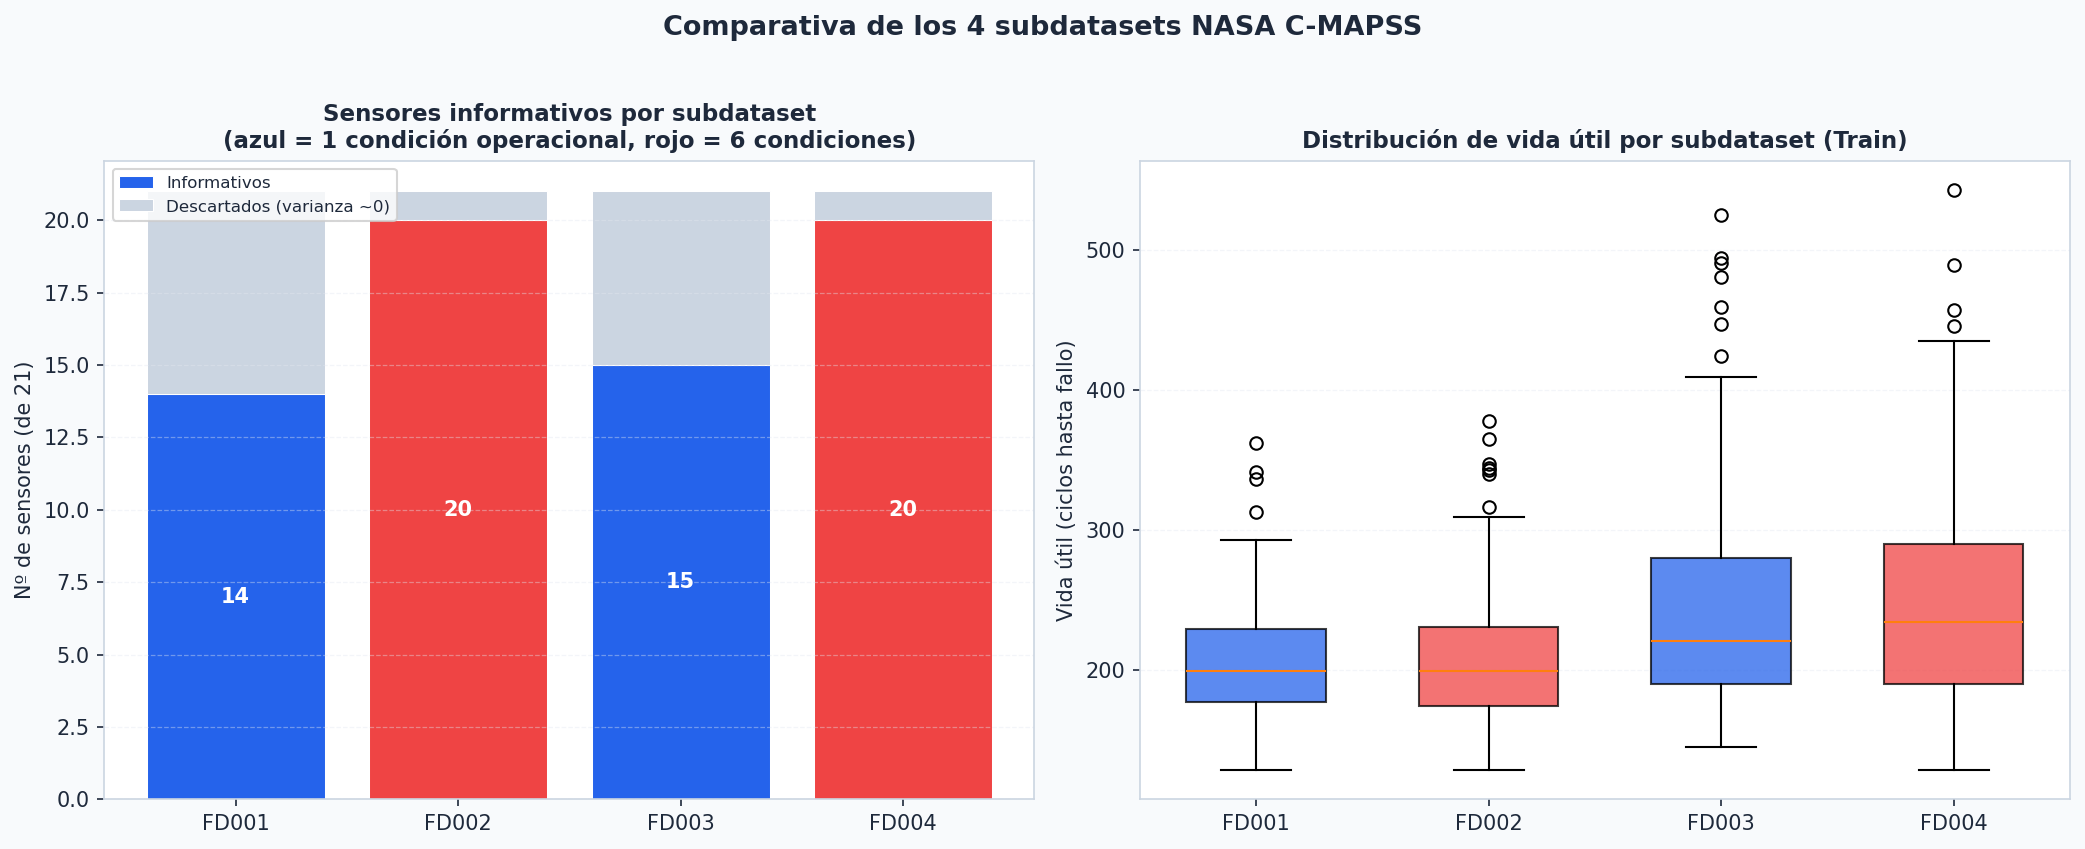

In [20]:
f1.plot_subsets_comparison(comparison_df, loaded,
                            save_path=f"{f0.FIG_DIR}/f1_05_subsets_comparison.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_05_subsets_comparison.png"))

### 7.1 Por qué FD002/FD004 necesitan normalización por régimen

El siguiente diagnóstico visual — los 6 regímenes de FD004 en el espacio `op_setting_1` / `op_setting_2` — es la evidencia directa: los clusters son claramente separables, así que un único `MinMaxScaler` global mezclaría en la misma escala mediciones tomadas en condiciones físicas distintas. FD004 se elige para esta demo por ser el caso más exigente del dataset (6 condiciones **y** 2 modos de fallo a la vez).

In [21]:
show_source(f1.plot_operating_conditions)

📍 plot_operating_conditions  —  scripts\fase1_carga_inspeccion.py:374
------------------------------------------------------------------------------
def plot_operating_conditions(train_df: pd.DataFrame, kmeans, subset: str,
                               save_path: str = None):
    """
    Dispersión de op_setting_1 vs. op_setting_2, coloreada por el
    régimen (k-means, ajustado en Fase 0) al que se asignó cada ciclo.
    Justifica visualmente por qué FD002/FD004 no pueden normalizarse
    con un único scaler global: los 6 clusters son claramente
    separables, es decir, los sensores se mueven en rangos distintos
    según el régimen operacional, no solo por degradación.
    """
    conditions = f0.assign_conditions(train_df, kmeans)
    n_conditions = len(np.unique(conditions))
    cmap = plt.get_cmap("tab10")

    fig, ax = plt.subplots(figsize=(8, 6))
    for cond_id in sorted(conditions.unique()):
        mask = conditions == cond_id
        ax.scatter(train_df.loc[mask, "os1"],

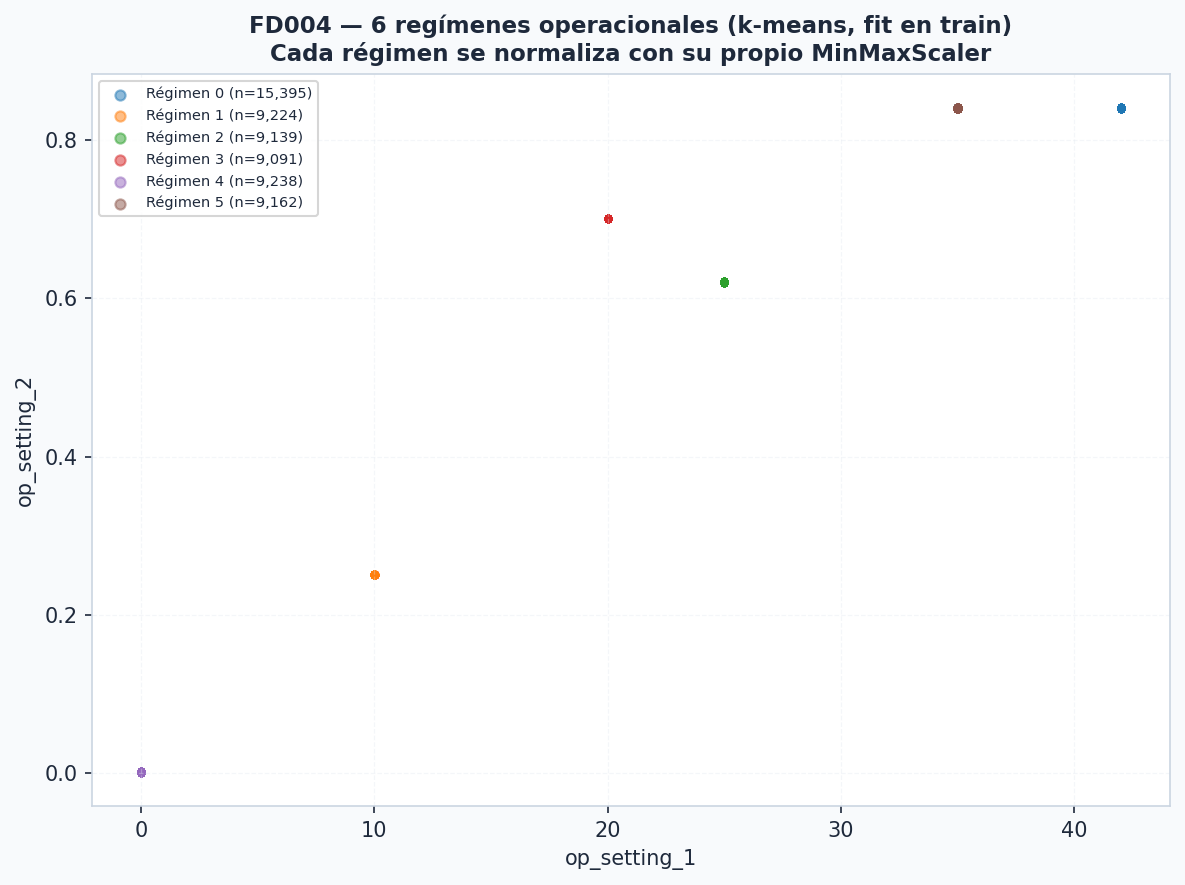

In [22]:
fd004_kmeans = loaded["FD004"]["norm_info"]["kmeans"]
f1.plot_operating_conditions(loaded["FD004"]["train"], fd004_kmeans, "FD004",
                              save_path=f"{f0.FIG_DIR}/f1_06_operating_conditions_fd004.png")
display(Image(filename=f"{f0.FIG_DIR}/f1_06_operating_conditions_fd004.png"))

### 7.2 Exportación

La tabla comparativa se guarda en `outputs/fase1_subsets_comparison.csv` para que otras fases (o el informe técnico) puedan referenciarla sin recalcularla.

In [23]:
comparison_df.to_csv(f"{f0.OUTPUT_DIR}/fase1_subsets_comparison.csv")
print(f"Guardado: {f0.OUTPUT_DIR}/fase1_subsets_comparison.csv")

Guardado: C:\Users\pardo\PROYECT_04\outputs/fase1_subsets_comparison.csv


## 8. Resumen

| Elemento | Resultado |
|---|---|
| Motores train / test | 100 / 100 |
| Vida útil (train) | 206.3 ± 46.3 ciclos (rango 128-362) — coincide con el informe técnico |
| Sensores informativos | 14 (coincide con Fase 0) |
| Normalización mostrada | Global (Fase 0) — ya no per-motor |
| Extensión (sección 7) | Comparativa FD001-FD004: FD002/FD004 normalizados por régimen (6 condiciones), 20 sensores informativos frente a 14-15 en FD001/FD003 |

**Siguiente paso:** Fase 2 (`fase2_feature_engineering.ipynb`) construye
las features de ventana deslizante sobre esta misma base.
